# Model Results Visualisation
Generates publication-quality figures for the results section.

**Run `python evaluate_models.py` first** — this notebook reads the
`models/predictions_*.csv` files it produces.

**Figures produced:**
1. ROC curves — baseline vs fine-tuned
2. Confusion matrices (side-by-side heatmaps)
3. Metric comparison bar chart
4. Prediction score distribution

In [2]:
import os
from pathlib import Path
# Always run from project root so relative paths work
os.chdir(Path(__file__).parent if "__file__" in dir() else Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import sys
sys.path.insert(0, str(Path.cwd()))  # project root after chdir

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

OUT_DIR   = Path('figures')
OUT_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path('models')  # absolute after chdir to project root

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

# Load predictions (produced by evaluate_models.py)
base_csv = MODEL_DIR / 'predictions_baseline.csv'
fine_csv = MODEL_DIR / 'predictions_finetuned.csv'

if not base_csv.exists() or not fine_csv.exists():
    print('ERROR: Run `python evaluate_models.py` first to generate prediction CSVs.')
else:
    df_base = pd.read_csv(base_csv)
    df_fine = pd.read_csv(fine_csv)
    print(f'Baseline predictions : {len(df_base):,} samples')
    print(f'Fine-tuned predictions: {len(df_fine):,} samples')
    print(df_base.head(3))

Baseline predictions : 56,693 samples
Fine-tuned predictions: 56,693 samples
   true_label  predicted_label  dyslexia_probability
0           0                0              0.554146
1           0                1              0.497023
2           0                0              0.587565


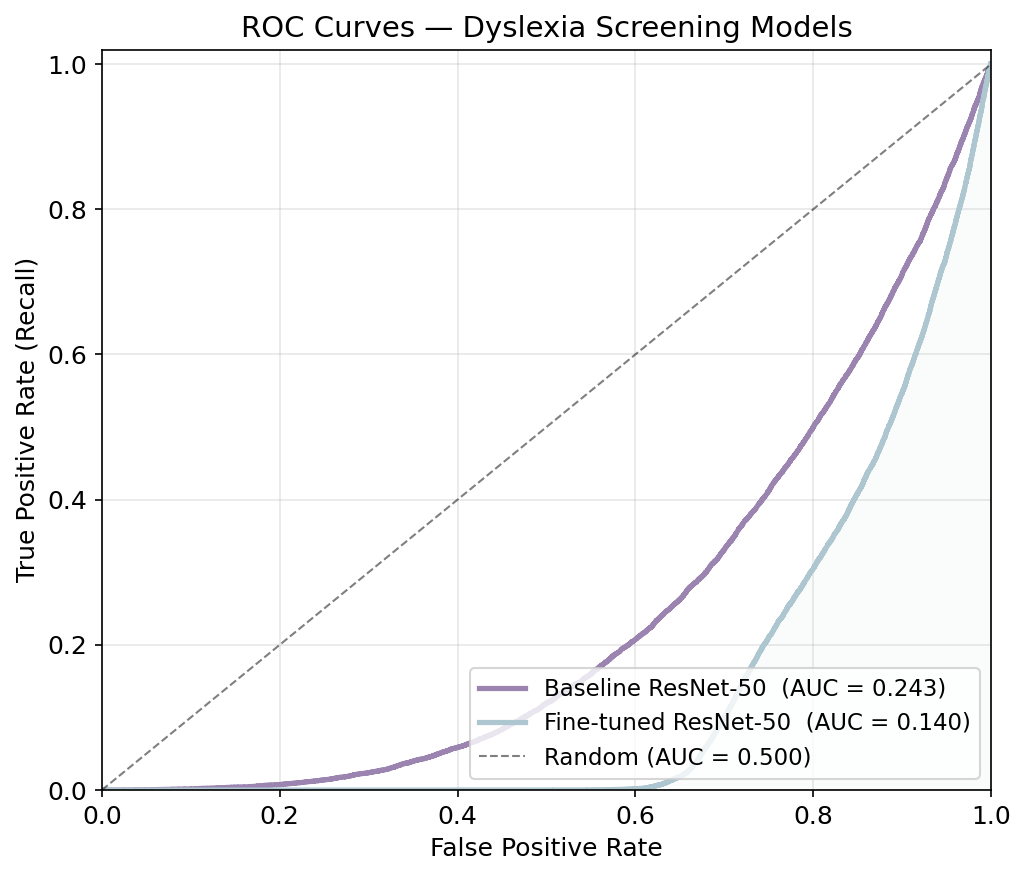

Saved fig4_roc_curves.png


In [3]:
# Figure 1 — ROC curves
fig, ax = plt.subplots(figsize=(7, 6))

for df, label, color in [
    (df_base, 'Baseline ResNet-50',   '#9B84B0'),
    (df_fine, 'Fine-tuned ResNet-50', '#AEC6CF'),
]:
    fpr, tpr, _ = roc_curve(df['true_label'], df['dyslexia_probability'])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{label}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — Dyslexia Screening Models')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.fill_between(fpr, tpr, alpha=0.05, color='#AEC6CF')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig4_roc_curves.png')
plt.show()
print('Saved fig4_roc_curves.png')

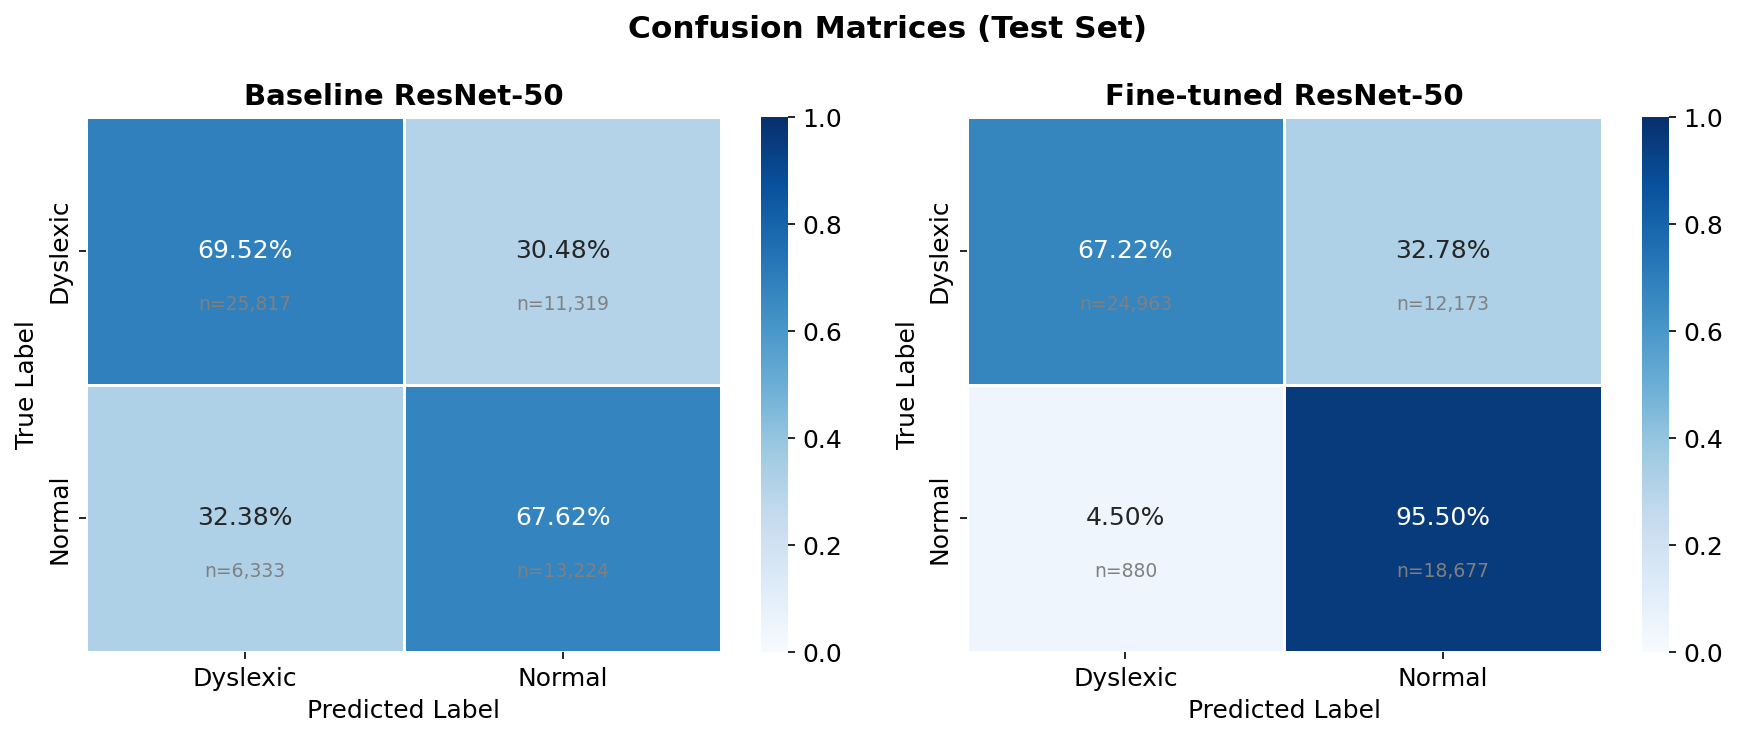

Saved fig5_confusion_matrices.png


In [4]:
# Figure 2 — Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices (Test Set)', fontsize=15, fontweight='bold')

for ax, df, title in [
    (axes[0], df_base, 'Baseline ResNet-50'),
    (axes[1], df_fine, 'Fine-tuned ResNet-50'),
]:
    cm = confusion_matrix(df['true_label'], df['predicted_label'])
    # Normalise by row (true label)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax,
                xticklabels=['Dyslexic', 'Normal'],
                yticklabels=['Dyslexic', 'Normal'],
                vmin=0, vmax=1, linewidths=0.5)
    # Also show raw counts
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.7, f'n={cm[i,j]:,}',
                    ha='center', va='center', fontsize=9, color='grey')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig5_confusion_matrices.png')
plt.show()
print('Saved fig5_confusion_matrices.png')

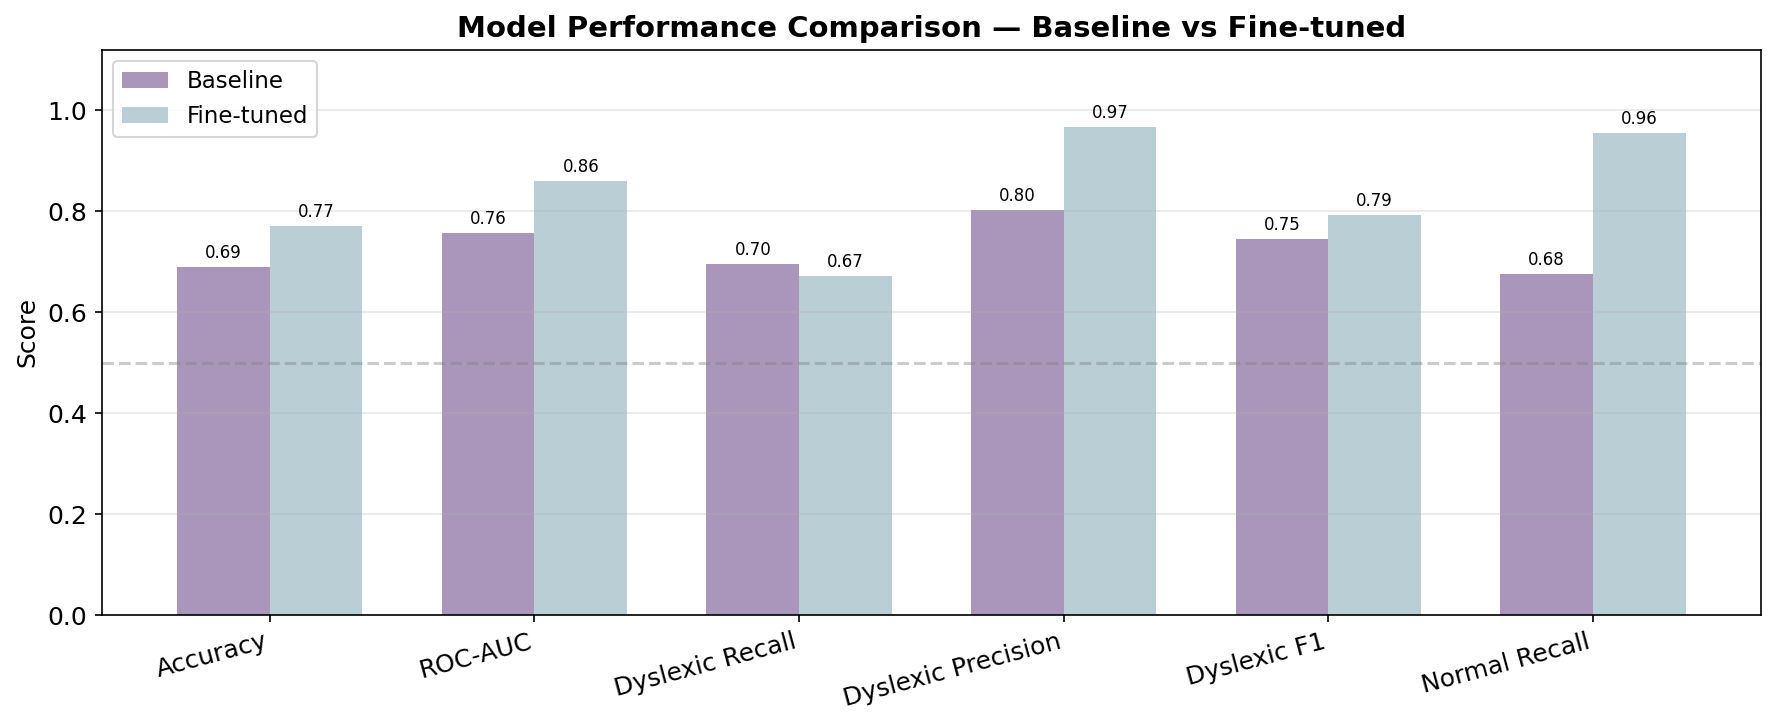

Saved fig6_metric_comparison.png


In [5]:
# Figure 3 — Metric comparison bar chart
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

def get_metrics(df):
    y, yp, ypr = df['true_label'], df['predicted_label'], df['dyslexia_probability']
    return {
        'Accuracy':          accuracy_score(y, yp),
        'ROC-AUC':           roc_auc_score(y, 1 - ypr),
        'Dyslexic Recall':   recall_score(y, yp, pos_label=0),
        'Dyslexic Precision':precision_score(y, yp, pos_label=0, zero_division=0),
        'Dyslexic F1':       f1_score(y, yp, pos_label=0, zero_division=0),
        'Normal Recall':     recall_score(y, yp, pos_label=1),
    }

m_base = get_metrics(df_base)
m_fine = get_metrics(df_fine)

metric_names = list(m_base.keys())
x = np.arange(len(metric_names))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - w/2, [m_base[k] for k in metric_names], w,
               label='Baseline', color='#9B84B0', alpha=0.85)
bars2 = ax.bar(x + w/2, [m_fine[k] for k in metric_names], w,
               label='Fine-tuned', color='#AEC6CF', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=15, ha='right')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Baseline vs Fine-tuned', fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.4, label='Random baseline')
ax.grid(axis='y', alpha=0.3)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig6_metric_comparison.png')
plt.show()
print('Saved fig6_metric_comparison.png')

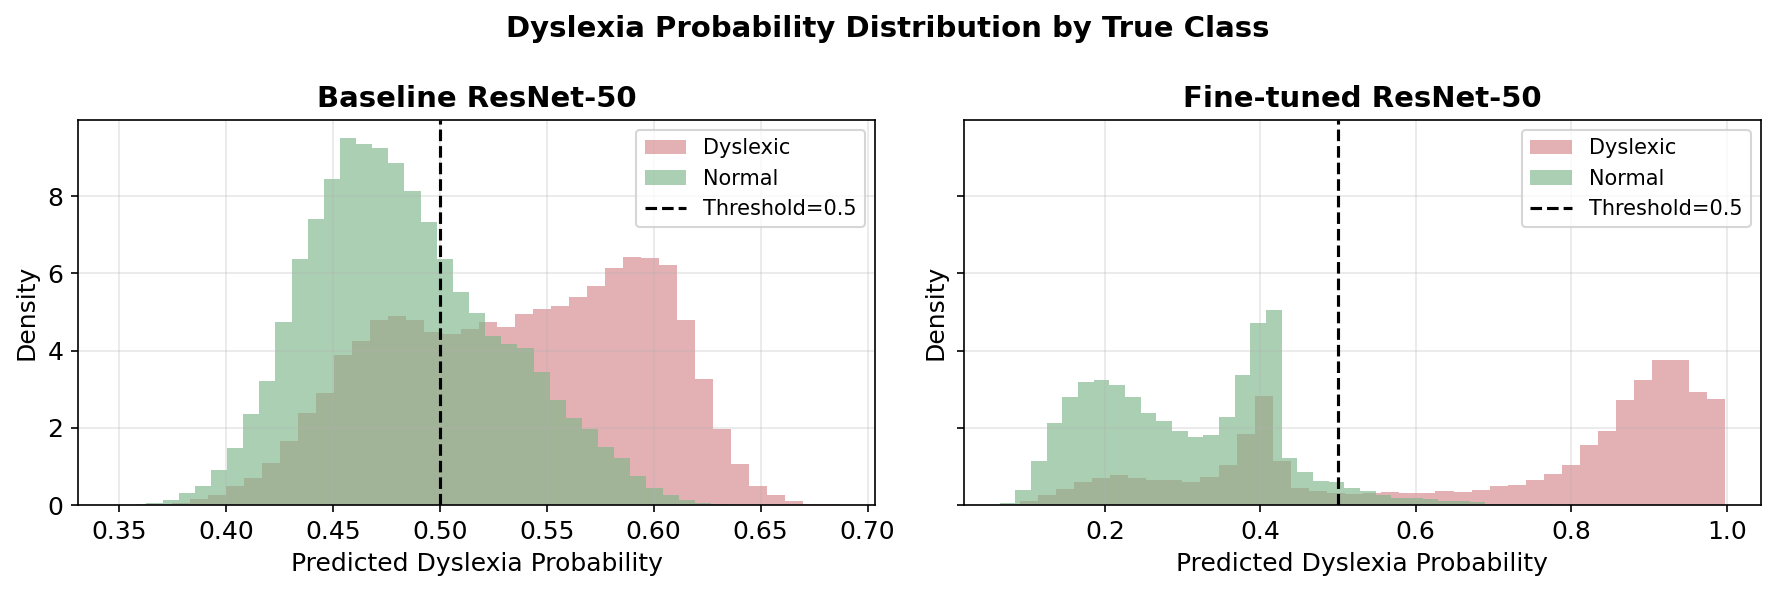

Saved fig7_score_distribution.png


In [6]:
# Figure 4 — Prediction score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig.suptitle('Dyslexia Probability Distribution by True Class', fontsize=14, fontweight='bold')

for ax, df, title in [
    (axes[0], df_base, 'Baseline ResNet-50'),
    (axes[1], df_fine, 'Fine-tuned ResNet-50'),
]:
    dys_probs = df[df['true_label']==0]['dyslexia_probability']
    nor_probs = df[df['true_label']==1]['dyslexia_probability']
    ax.hist(dys_probs, bins=40, alpha=0.65, color='#D4888A',
            label='Dyslexic', density=True)
    ax.hist(nor_probs, bins=40, alpha=0.65, color='#7FB68A',
            label='Normal',   density=True)
    ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold=0.5')
    ax.set_xlabel('Predicted Dyslexia Probability')
    ax.set_ylabel('Density')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig7_score_distribution.png')
plt.show()
print('Saved fig7_score_distribution.png')

In [7]:
print('\nAll figures saved to:', OUT_DIR.resolve())
print('Use these in your paper/article!')


All figures saved to: C:\Users\ASUS\Desktop\Early-screening-of-dyslexia-\figures
Use these in your paper/article!
